# **SafeFlow AI: CSCI323 Group Project**

**Import Libraries & Toolkits**

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

c:\Users\Lechu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("berkanoztas/synthetic-transaction-monitoring-dataset-aml")
finalpath= path + "/SAML-D.csv"
df = pd.read_csv(finalpath)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    object 
 1   Date                    object 
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        object 
 6   Received_currency       object 
 7   Sender_bank_location    object 
 8   Receiver_bank_location  object 
 9   Payment_type            object 
 10  Is_laundering           int64  
 11  Laundering_type         object 
dtypes: float64(1), int64(3), object(8)
memory usage: 870.2+ MB


In [3]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


**Data Analysis & Feature Engineering**

In [4]:
#Find Any Null values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64


In [5]:
#Drop any rows with null values
if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)
    print("Null values dropped.")
else:
    print("\nNo null values found.")


No null values found.


In [6]:
#Creating a timestamp feature
df['timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['hour_'] = df['timestamp'].dt.hour
df['day_'] = df['timestamp'].dt.dayofweek
df['month_'] = df['timestamp'].dt.month

- The 'hour_', 'day_' and 'month_' features can be used to distinguish between normal transactions and illicit ones, which are usually carried out during unusual timings (late night or weekends) to avoid detection.

In [7]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,timestamp,hour_,day_,month_
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:19,10,4,10
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out,2022-10-07 10:35:20,10,4,10
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out,2022-10-07 10:35:20,10,4,10
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In,2022-10-07 10:35:21,10,4,10
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:21,10,4,10


**Anomaly Detection**

In [8]:
#Using IsolationForest to detect Outliers
outlier_df = df.select_dtypes(include=['number']).drop(columns=['Is_laundering','Sender_account','Receiver_account'])
outliers_if = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1) #'contamination=0.01'- considering 1% transactions will be ouliers.
outliers_if.fit(outlier_df)
df['anomaly_score'] = outliers_if.decision_function(outlier_df)

In [9]:
df['anomaly_score'].describe()

count    9.504852e+06
mean     1.298445e-01
std      4.085509e-02
min     -1.209698e-01
25%      1.082611e-01
50%      1.371665e-01
75%      1.598498e-01
max      1.982302e-01
Name: anomaly_score, dtype: float64

In [10]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,timestamp,hour_,day_,month_,anomaly_score
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:19,10,4,10,0.165493
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out,2022-10-07 10:35:20,10,4,10,0.171149
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out,2022-10-07 10:35:20,10,4,10,0.145629
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In,2022-10-07 10:35:21,10,4,10,0.159160
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:21,10,4,10,0.156375


- The anomaly_score shows how unusual a transaction is, with lower values meaning more unusual and higher scores represent more normal transactions.

Visualizing detetected Outliers against different features

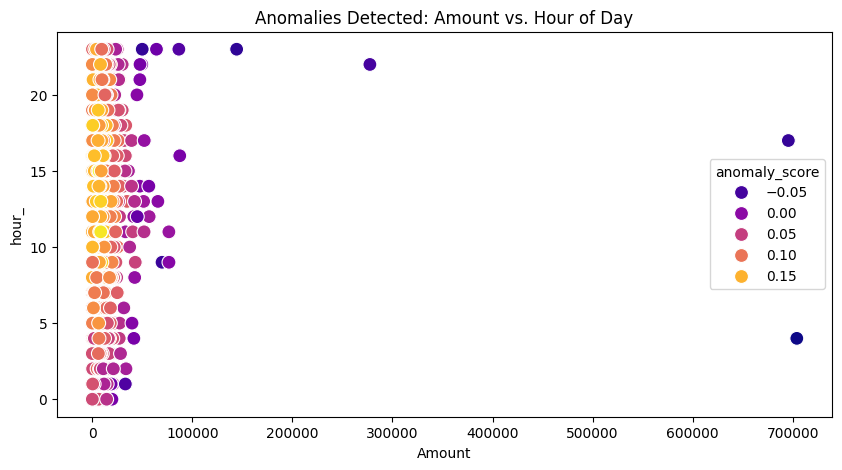

In [11]:
#Against Hour of Day
plt.figure(figsize=(10, 5))
scatter1 = sns.scatterplot(
    data=df.sample(n=2000,random_state=42), 
    x='Amount',
    y='hour_',
    hue='anomaly_score',
    palette='plasma',
    s=100)
plt.title('Anomalies Detected: Amount vs. Hour of Day')
plt.show()

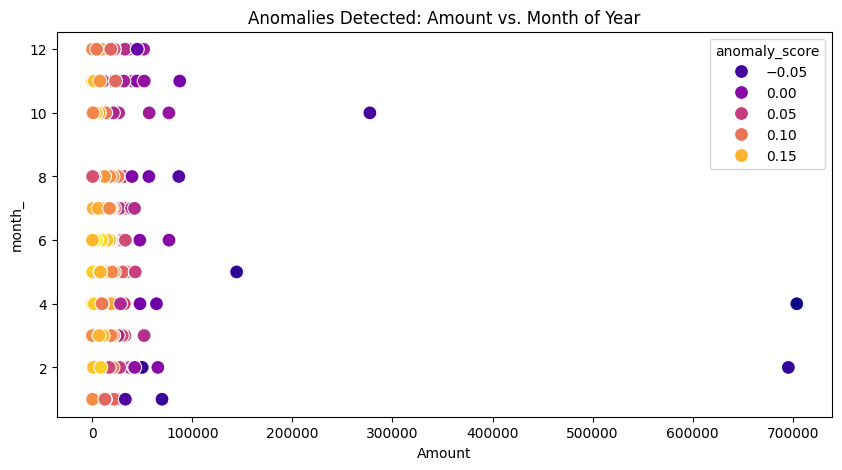

In [12]:
#Against Month of Year
plt.figure(figsize=(10, 5))
scatter1 = sns.scatterplot(
    data=df.sample(n=2000,random_state=42), 
    x='Amount',
    y='month_',
    hue='anomaly_score',
    palette='plasma',
    s=100)
plt.title('Anomalies Detected: Amount vs. Month of Year')
plt.show()

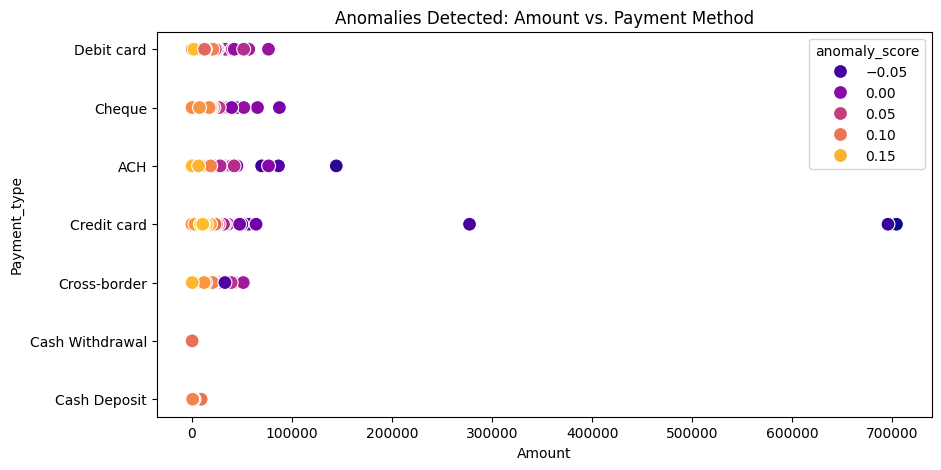

In [13]:
#Against Payment Methods
plt.figure(figsize=(10, 5))
scatter1 = sns.scatterplot(
    data=df.sample(n=2000,random_state=42), 
    x='Amount',
    y='Payment_type',
    hue='anomaly_score',
    palette='plasma',
    s=100)
plt.title('Anomalies Detected: Amount vs. Payment Method')
plt.show()

- The scatterplots displays the anomalies detected by IsolationForest for a certain amount of data against 3 crucial features. We can visually confirm the presence of outliers in the dataset and the 'anomaly_score' created for each row will help the final model for a more precise predictions. 

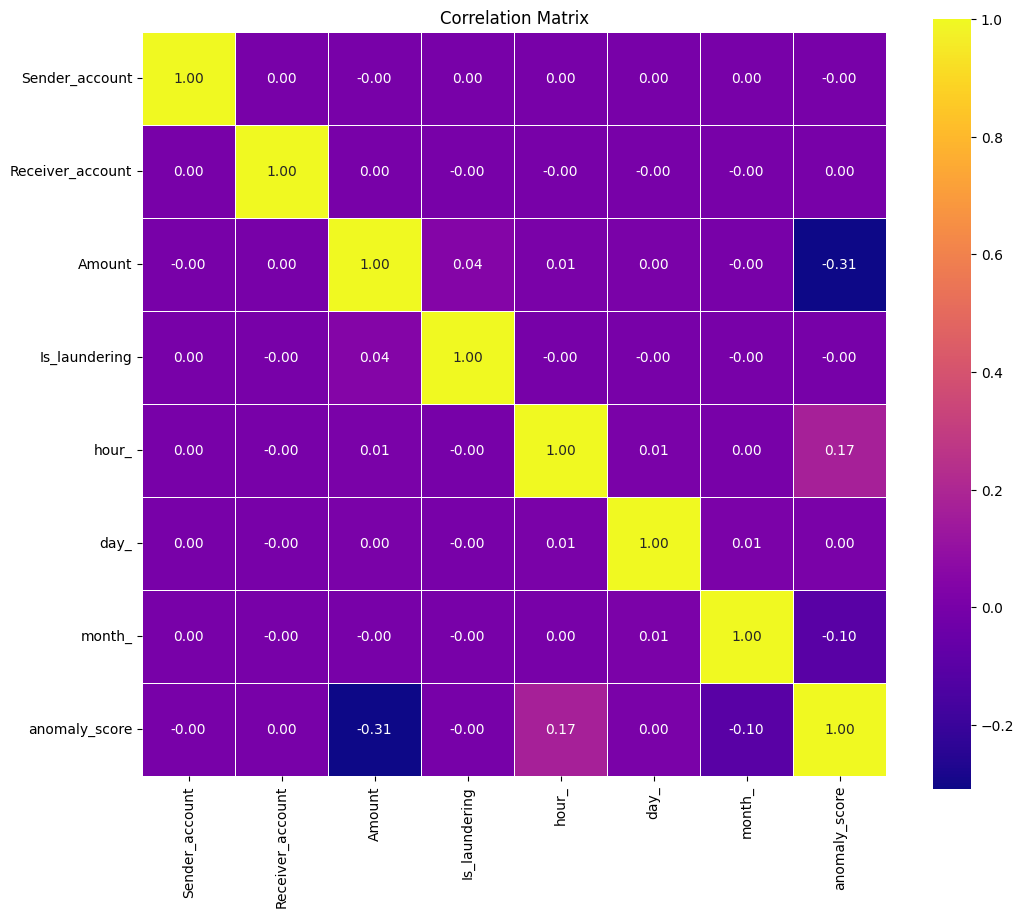

In [14]:
#Correlation Analysis
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True,fmt=".2f",cmap='plasma',square=True, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=12)
plt.show()

- The Correlation Matrix doesn't show any multicollinearity between the features, hence no redundant information. This means we do not have any restriction in model selection.

In [15]:
#Drop inessential columns
df = df.drop(columns=['timestamp','Laundering_type']) #'Laundering_type' is a label, can result in leakage and affect the results

In [16]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,hour_,day_,month_,anomaly_score
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,10,4,10,0.165493
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,10,4,10,0.171149
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,10,4,10,0.145629
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,10,4,10,0.159160
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,10,4,10,0.156375


**Data Partitioning**

In [17]:
#Data Parttioaning is done prior to any preprocessing to prevent data leakage. 
X = df.drop(columns=['Time', 'Date','Is_laundering','Sender_account','Receiver_account']) #Sender_account, Receiver_account are identifiers, not labels.
y = df['Is_laundering']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, #20% of data is allocated for testing
                                                    random_state=42, 
                                                    stratify=y) #for balanced mix in both training and testing set

In [18]:
print("Training set size:", X_train.shape[0], "rows")
print("Testing set size:", X_test.shape[0], "rows")

Training set size: 7603881 rows
Testing set size: 1900971 rows


**Pre-Processing**

In [19]:
#Split the Categorical and Numerical Columns in Training Data
num_columns = X.select_dtypes(include=[np.number]).columns.to_list()
cat_columns = X.select_dtypes(include=['object','category']).columns.to_list()

In [20]:
#Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_columns)
    ])

#Fit-transform training data and transform test data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

**Low Variance Feature Removal**

In [21]:
#Finding features with low variance
preprocessed_feature_names = preprocessor.get_feature_names_out()
print("Features before VarianceThreshold:", preprocessed_feature_names.tolist())

Features before VarianceThreshold: ['num__Amount', 'num__hour_', 'num__day_', 'num__month_', 'num__anomaly_score', 'cat__Payment_currency_Dirham', 'cat__Payment_currency_Euro', 'cat__Payment_currency_Indian rupee', 'cat__Payment_currency_Mexican Peso', 'cat__Payment_currency_Moroccan dirham', 'cat__Payment_currency_Naira', 'cat__Payment_currency_Pakistani rupee', 'cat__Payment_currency_Swiss franc', 'cat__Payment_currency_Turkish lira', 'cat__Payment_currency_UK pounds', 'cat__Payment_currency_US dollar', 'cat__Payment_currency_Yen', 'cat__Received_currency_Dirham', 'cat__Received_currency_Euro', 'cat__Received_currency_Indian rupee', 'cat__Received_currency_Mexican Peso', 'cat__Received_currency_Moroccan dirham', 'cat__Received_currency_Naira', 'cat__Received_currency_Pakistani rupee', 'cat__Received_currency_Swiss franc', 'cat__Received_currency_Turkish lira', 'cat__Received_currency_UK pounds', 'cat__Received_currency_US dollar', 'cat__Received_currency_Yen', 'cat__Sender_bank_locat

In [22]:
selector = VarianceThreshold(0.01) #0.01 indicates to remove features in which a value appears more than 99% times.
X_train_final = selector.fit_transform(X_train_preprocessed)
X_test_final = selector.transform(X_test_preprocessed)

selected_features = np.array(preprocessed_feature_names)[selector.get_support()]
print("Features kept after VarianceThreshold:", selected_features.tolist())

Features kept after VarianceThreshold: ['num__Amount', 'num__hour_', 'num__day_', 'num__month_', 'num__anomaly_score', 'cat__Payment_currency_Euro', 'cat__Payment_currency_UK pounds', 'cat__Received_currency_Euro', 'cat__Received_currency_UK pounds', 'cat__Sender_bank_location_UK', 'cat__Receiver_bank_location_UK', 'cat__Payment_type_Cash Deposit', 'cat__Payment_type_Cash Withdrawal', 'cat__Payment_type_Cheque', 'cat__Payment_type_Credit card', 'cat__Payment_type_Cross-border', 'cat__Payment_type_Debit card']


- Features showing low variance are removed from the training and testing set, which cleans the datasets and helps the models to focus more on the important fetaures.

In [23]:
#Handling Imbalanced Data with SMOTE
print("Unbalanced class distribution:", y.value_counts())

Unbalanced class distribution: Is_laundering
0    9494979
1       9873
Name: count, dtype: int64


In [24]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)
print("Balanced class distribution:", y_train_resampled.value_counts())

Balanced class distribution: Is_laundering
0    7595983
1    7595983
Name: count, dtype: int64


**Model Selection and Training**

- Given our large, tabular dataset, with over 9 million rows, the goal is to find a model that is both highly accurate and computationally efficient. 
- We have selected four scalable and powerful models that are able to accomadate large datasets and make predictions efficiently.

In [25]:
#LogisticRegression: A fast and interpretable classification model that can be used as a baseline to compare complex models with excellent scalability.
lr_model = LogisticRegression(solver='saga', random_state=42, max_iter=5000)

#RandomForestClassifier: An ensemble model that is excellent capturing complex relationships, effective for large complex projects being very scalable and robust.
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

#AdaBoostClassifier: An adaptive ensemble model that learns from its mistakes, providing high accuracy for complex predictions, yet slower in performance   .
ad_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2), random_state=42)

#GaussianNB: Naive Bayes model is fast to train, which gives a big upper hand for large datasets.
nb_model = GaussianNB()

models = {'LogisticRegression': lr_model,
          'RandomForestClassifier': rf_model,
          'AdaBoostClassifier': ad_model,
          'GaussianNB': nb_model}

In [26]:
#Define Paramter dictionary for all the models

#LogisticRegression
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'max_iter': [2000, 5000]
}

#RandomForestClassifier
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

#AdaBoostClassifier
ad_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0],
    'estimator__max_depth': [1 ,2, 3]
}

param_dict = {
    'LogisticRegression': lr_params,
    'RandomForestClassifier': rf_params,
    'AdaBoostClassifier': ad_params
}


**Hyperparameter Tuning**

- We use GridsearchCV and RandomizedSearchCV methods for parameter tuning as it scales well to large datasets and saving compute time for tuning parameters for complex models like RandomForest and Adaboost.


In [ ]:
#StratifiedShuffleSplit is used in highly imbalanced data, to mainatain the ratio between test and train data.
#Here we are using it to select a tuning subset, which will help to maintaine balance and also less time-consumption for cross-validation and not enough computational power for large resources. (approx. subset size: 300K)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.98, random_state=42)
for train_index, test_index in sss.split(X_train_resampled, y_train_resampled):
    X_tuning_sample = X_train_resampled[train_index]
    y_tuning_sample = y_train_resampled[train_index]

In [28]:
#For LogisticRegression
lr_search = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_params,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

lr_search.fit(X_tuning_sample, y_tuning_sample)
best_lr = lr_search.best_estimator_
print("Best Logistic Regression Params:", lr_search.best_params_)

Best Logistic Regression Params: {'C': 10, 'max_iter': 2000, 'solver': 'liblinear'}


In [29]:
#For RandomForestClassifier
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_params,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
)

rf_search.fit(X_tuning_sample, y_tuning_sample)
best_rf = rf_search.best_estimator_
print("Best Random Forest Params:", rf_search.best_params_)

Best Random Forest Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 30, 'class_weight': 'balanced'}


In [30]:
#For Adaboost Classifier
ad_search = GridSearchCV(
    estimator=ad_model,
    param_grid=ad_params,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

ad_search.fit(X_tuning_sample, y_tuning_sample)
best_ad = ad_search.best_estimator_
print("Best AdaBoost Params:", ad_search.best_params_)

Best AdaBoost Params: {'estimator__max_depth': 3, 'learning_rate': 1.0, 'n_estimators': 200}


In [31]:
#For GaussianNB

#GaussianNB is a probabilistic model that can make strong as sumption, and it often performs well without parameter tuning.
nb_model.fit(X_train_resampled.toarray(), y_train_resampled)

GaussianNB()

**Model Evaluation**

In [32]:
def evaluate_test(model_name, y_test, y_pred):
    print(f"\nModel: {model_name}\n")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC:   {roc_auc_score(y_test, y_pred):.4f}\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred),"\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred),"\n")

print("--- Evaluation Results ---")
y_pred_lr = best_lr.predict(X_test_final)
evaluate_test("Logistic Regression", y_test, y_pred_lr)

y_pred_rf = best_rf.predict(X_test_final)
evaluate_test("Random Forest", y_test, y_pred_rf)

y_pred_ad = best_ad.predict(X_test_final)
evaluate_test("AdaBoost", y_test, y_pred_ad)

y_pred_nb = nb_model.predict(X_test_final.toarray()) #GaussianNB works only on dense arrays
evaluate_test("GaussianNB", y_test, y_pred_nb)

--- Evaluation Results ---

Model: Logistic Regression

Precision: 0.0038
Recall:    0.6339
F1 Score:  0.0075
ROC AUC:   0.7302

Confusion Matrix:
[[1569286  329710]
 [    723    1252]] 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.90   1898996
           1       0.00      0.63      0.01      1975

    accuracy                           0.83   1900971
   macro avg       0.50      0.73      0.46   1900971
weighted avg       1.00      0.83      0.90   1900971
 


Model: Random Forest

Precision: 0.0065
Recall:    0.2942
F1 Score:  0.0128
ROC AUC:   0.6239

Confusion Matrix:
[[1810809   88187]
 [   1394     581]] 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1898996
           1       0.01      0.29      0.01      1975

    accuracy                           0.95   1900971
   macro avg       0.50      0.62      0.49   1900971
weighted a

- The F1 Score is the top priority when evaluating an imbalanced dataset because it provides a balanced measure of both precision (how many predicted positives are actually correct) and recall (how many actual positives were correctly identified).
- After evaluating all the four models, we chose **AdaBoost** because it showed the highest F1 Score (0.0187) and Precision (0.0097), indicating the best trade-off between precision and recall.
- While other models like Logistic Regression and GaussianNB had higher recall, their extremely low precision reduced their F1 scores.
- AdaBoost strikes as the most effective balance, making it the most suitable model underthis evaluation criterion.

In [33]:
#save the chosen model
joblib.dump(best_ad, 'best_model_ad.joblib')

['best_model_ad.joblib']

**Sample Testing on Trained Model**

In [34]:
#Load the saved model
loaded_model = joblib.load('best_model_ad.joblib')

In [ ]:
#Pick a random sample
positive_indices = np.where(y_test == 1)[0]
pos_index = random.choice(positive_indices)

#Get the corresponding feature row and true label
sample = X_test_final[pos_index]
sample_reshaped = sample.reshape(1, -1)
actual_label = y_test.iloc[pos_index]

#Predict using the model
predicted_label = loaded_model.predict(sample_reshaped)[0]

print(f"Random Sample Index: {pos_index}")
print(f"Actual Label: {actual_label}")
print(f"Predicted Label: {predicted_label}")

if predicted_label == actual_label:
    if predicted_label == 0:
        print("\nPrediction is correct. This is a normal transaction.")
    else:
        print("\nPrediction is correct. This is a possible Money-Laundering Transaction.\n")
        print("---Transaction Details---")
        print("Transaction Date:", df.iloc[pos_index]["Date"])
        print("Transaction Time:", df.iloc[pos_index]["Time"])
        print("Sender Account:", df.iloc[pos_index]["Sender_account"])
        print("Receiver Account:", df.iloc[pos_index]["Receiver_account"])
        print("Transaction Amount:", df.iloc[pos_index]["Amount"])
        print("Payment Currency:", df.iloc[pos_index]["Payment_currency"])
        print("Transaction Type:", df.iloc[pos_index]["Payment_type"])

else:
    print("\nPrediction is incorrect.")
    if actual_label == 1:
        print("This was a possible Money-Laundering transaction.")
    else:
        print("This was a normal transaction.")

Random Sample Index: 1322550
Actual Label: 1
Predicted Label: 1

Prediction is correct. This is a possible Money-Laundering Transaction.

---Transaction Details---
Transaction Date: 2022-11-21
Transaction Time: 11:50:25
Sender Account: 8480336062
Receiver Account: 3991121540
Transaction Amount: 156892.69
Payment Currency: UK pounds
Transaction Type: ACH
